In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
class Value:

    def __init__(self, data, _children=(),_op='',label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"


    def __add__(self, other):
        out  = Value(self.data + other.data, (self,other),'+')
        return out

    def __mul__(self,other):
        out = Value(self.data * other.data, (self,other),'*')
        return out

a = Value(2,label='a')
b = Value(3,label='b' )
c = Value(10,label='c')
e = a*b; e.label = 'e'
#a + b
#print(a*b)
#print(a*b +c)
d = e + c; d.label = 'd'
d
f = Value(-2.0,label='f')
L = d*f;L.label = 'L'
L

    

Value(data=-32.0)

In [24]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data%.4f }" % (n.label, n.data), shape='record')
        if n._op:
            dot.node(name = uid +n._op, label = n._op)
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

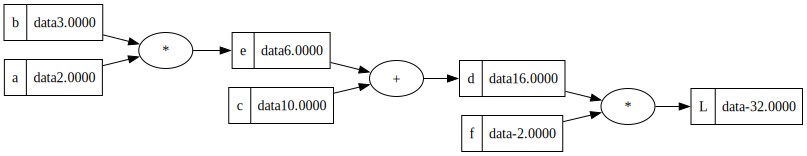

In [25]:
draw_dot(L)